# Non-Metric Multidimensional Scaling (NMDS) in R

## Overview

NMDS is a rank-based ordination method that represents the **rank-order** of pairwise dissimilarities in a low-dimensional space. Unlike PCA, it makes no linearity assumptions and works with any dissimilarity metric — making it the most widely used ordination method in community ecology.

| Property | NMDS |
|---|---|
| Assumptions | None about data distribution or linearity |
| Input | Any dissimilarity matrix |
| Output axes | No inherent meaning — axes can be rotated freely |
| Stress | Goodness-of-fit measure: how well 2D configuration represents true distances |
| Convergence | Iterative — run multiple times from random starts to find global minimum |

**Stress interpretation (Kruskal's rule of thumb):**

| Stress | Interpretation |
|---|---|
| < 0.05 | Excellent — near perfect representation |
| 0.05–0.10 | Good |
| 0.10–0.20 | Acceptable — some distortion |
| > 0.20 | Poor — consider 3 dimensions or a different method |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Visualizing community composition differences across habitat types or along disturbance gradients; comparing invertebrate assemblages between reference and impacted sites |
| **Healthcare** | Visualizing microbiome composition differences between patient groups; comparing immune cell profiles |
| **Finance** | Visualizing portfolio similarity structure across funds or time periods |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)      # metaMDS(), envfit(), ordiellipse()
library(ggrepel)    # non-overlapping text labels

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute



## Data

We use a simulated benthic invertebrate community matrix: 45 sites × 20 species, three habitat types. This mirrors real macroinvertebrate survey data directly.

In [2]:
# ── Simulate community matrix ─────────────────────────────────────────────────
n_sites <- 45; n_sp <- 20
habitat <- rep(c("reference", "degraded", "restored"), each = 15)

ref_means  <- c(8,7,6,5,5,4,3,3,2,2,1,1,1,0,0,0,0,0,0,0)
deg_means  <- c(0,0,1,1,2,3,4,5,6,7,8,6,4,3,2,1,1,1,0,0)
rest_means <- c(4,4,4,3,3,3,3,2,2,2,2,2,1,1,1,1,0,0,0,0)

sim_comm <- function(n, mu, sd = 0.7)
  t(replicate(n, pmax(round(exp(rnorm(n_sp, log(mu + 0.1), sd))), 0L)))

comm_mat <- rbind(sim_comm(15, ref_means),
                  sim_comm(15, deg_means, sd = 1.0),
                  sim_comm(15, rest_means, sd = 0.8))
rownames(comm_mat) <- paste0("site", 1:n_sites)
colnames(comm_mat) <- paste0("sp",   1:n_sp)

env_df <- tibble(
  site    = paste0("site", 1:n_sites),
  habitat = factor(habitat, levels = c("reference", "degraded", "restored")),
  pH      = c(rnorm(15, 7.8, 0.3), rnorm(15, 6.5, 0.6), rnorm(15, 7.2, 0.4)),
  nitrate = c(rnorm(15, 0.5, 0.2), rnorm(15, 3.5, 1.0), rnorm(15, 1.5, 0.5))
)
cat(sprintf("Community matrix: %d sites × %d species\n", nrow(comm_mat), ncol(comm_mat)))

Community matrix: 45 sites × 20 species


---

## Fitting NMDS with `vegan::metaMDS()`

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1415385 
Run 1 stress 0.1491417 
Run 2 stress 0.1446345 
Run 3 stress 0.1491876 
Run 4 stress 0.1398279 
... New best solution
... Procrustes: rmse 0.07702738  max resid 0.230367 
Run 5 stress 0.139567 
... New best solution
... Procrustes: rmse 0.07380343  max resid 0.1983526 
Run 6 stress 0.1454279 
Run 7 stress 0.1443535 
Run 8 stress 0.1454235 
Run 9 stress 0.1497134 
Run 10 stress 0.1421926 
Run 11 stress 0.1397245 
... Procrustes: rmse 0.04064655  max resid 0.2051816 
Run 12 stress 0.1396161 
... Procrustes: rmse 0.02572695  max resid 0.1271287 
Run 13 stress 0.1404217 
Run 14 stress 0.1373402 
... New best solution
... Procrustes: rmse 0.04985738  max resid 0.2037416 
Run 15 stress 0.1379293 
Run 16 stress 0.1447676 
Run 17 stress 0.1405956 
Run 18 stress 0.1425288 
Run 19 stress 0.1411079 
Run 20 stress 0.1430717 
Run 21 stress 0.1480899 
Run 22 stress 0.1456726 
Run 23 stress 0.1473215 
Run 24 stress 0.

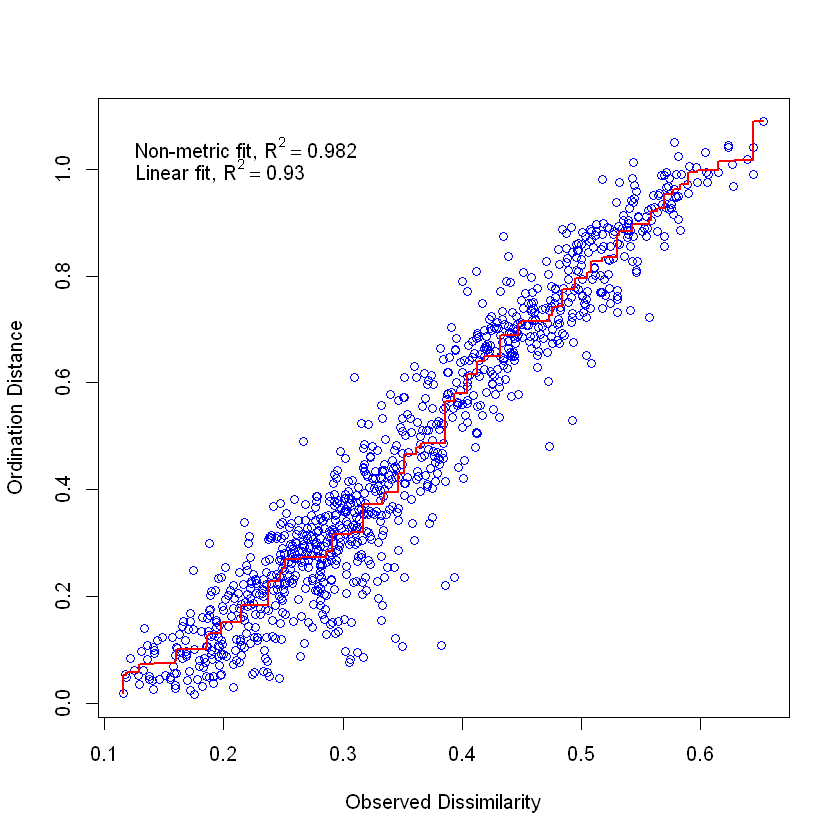

In [3]:
# ── Fit NMDS ──────────────────────────────────────────────────────────────────
nmds <- vegan::metaMDS(
  comm_mat,
  distance = "bray",    # Bray-Curtis: default for abundance data
  k        = 2,         # number of dimensions (usually 2 for visualization)
  trymax   = 100,       # max random starts — increase if convergence fails
  autotransform = TRUE  # applies sqrt then Wisconsin transformation automatically
                        # set to FALSE if you pre-transformed
)
print(nmds)
# Key output:
#   Stress: goodness-of-fit (lower = better; < 0.20 acceptable; < 0.10 good)
#   Converged: whether a stable solution was found

# ── Check stress ──────────────────────────────────────────────────────────────
cat(sprintf("\nFinal stress: %.4f\n", nmds$stress))
cat(sprintf("Stress interpretation: %s\n",
            dplyr::case_when(
              nmds$stress < 0.05  ~ "Excellent",
              nmds$stress < 0.10  ~ "Good",
              nmds$stress < 0.20  ~ "Acceptable",
              TRUE                ~ "Poor — consider k=3 or different method"
            )))

# ── Stressplot (Shepard diagram) ──────────────────────────────────────────────
vegan::stressplot(nmds)
# Points along the step-function line = good fit
# R² (non-metric): how well rank-order of distances is preserved
# R² (linear): how well actual distances are preserved

---

## Ordination Plot

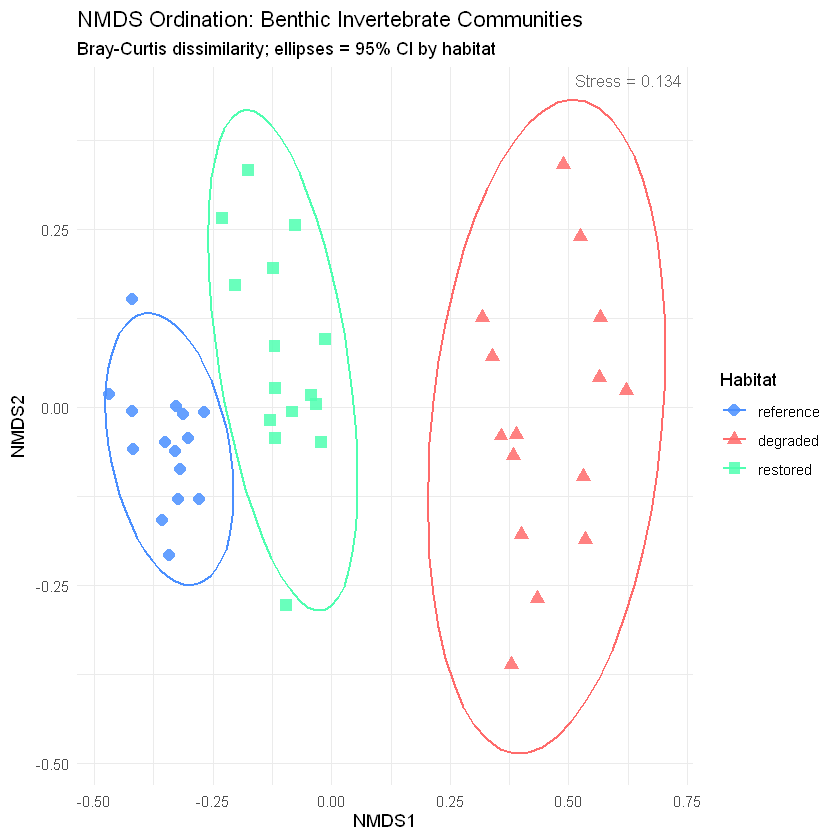

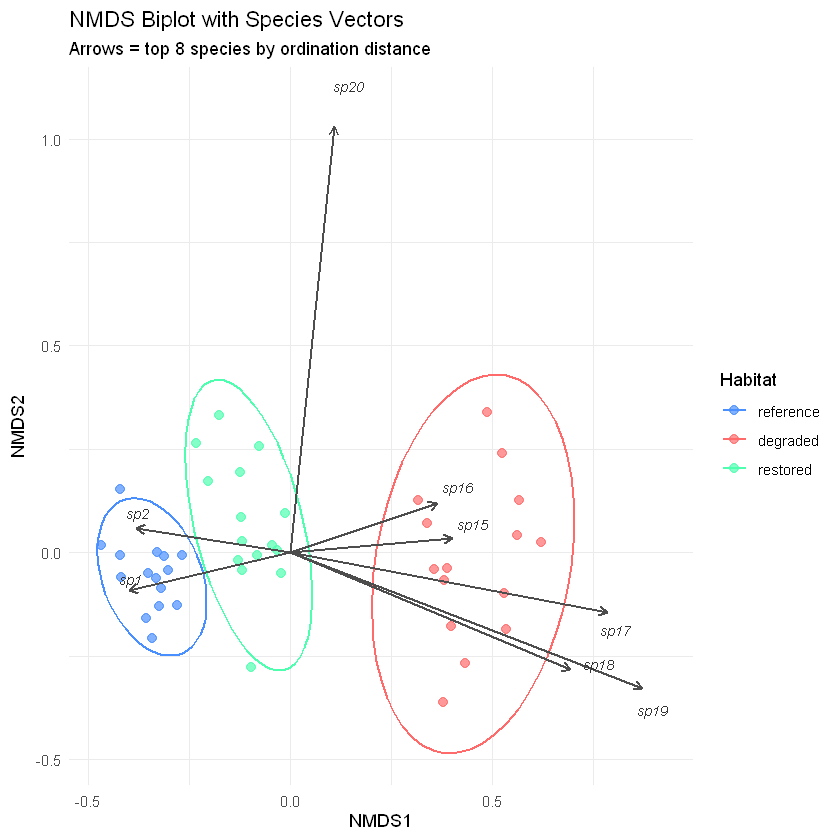

In [4]:
# ── Extract site scores ───────────────────────────────────────────────────────
site_scores <- as.data.frame(vegan::scores(nmds, display = "sites")) %>%
  rownames_to_column("site") %>%
  left_join(env_df, by = "site")

# ── Extract species scores ────────────────────────────────────────────────────
sp_scores <- as.data.frame(vegan::scores(nmds, display = "species")) %>%
  rownames_to_column("species")

# ── Basic ordination plot ─────────────────────────────────────────────────────
ggplot(site_scores, aes(x = NMDS1, y = NMDS2, color = habitat, shape = habitat)) +
  geom_point(size = 3, alpha = 0.85) +
  stat_ellipse(level = 0.95, linewidth = 0.8) +
  annotate("text", x = Inf, y = Inf,
           label = sprintf("Stress = %.3f", nmds$stress),
           hjust = 1.1, vjust = 1.5, size = 3.5, color = "gray40") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  scale_shape_manual(values = c(16, 17, 15)) +
  labs(title = "NMDS Ordination: Benthic Invertebrate Communities",
       subtitle = "Bray-Curtis dissimilarity; ellipses = 95% CI by habitat",
       color = "Habitat", shape = "Habitat") +
  theme_minimal()

# ── Add species vectors for most influential species ──────────────────────────
# Filter to species that are most extreme on either axis
sp_extreme <- sp_scores %>%
  mutate(dist = sqrt(NMDS1^2 + NMDS2^2)) %>%
  slice_max(dist, n = 8)

ggplot() +
  geom_point(data = site_scores,
             aes(x = NMDS1, y = NMDS2, color = habitat),
             size = 2.5, alpha = 0.7) +
  stat_ellipse(data = site_scores,
               aes(x = NMDS1, y = NMDS2, color = habitat),
               level = 0.95, linewidth = 0.7) +
  geom_segment(data = sp_extreme,
               aes(x = 0, y = 0, xend = NMDS1 * 0.8, yend = NMDS2 * 0.8),
               arrow = arrow(length = unit(0.2, "cm")),
               color = "gray30", linewidth = 0.6) +
  ggrepel::geom_text_repel(data = sp_extreme,
                            aes(x = NMDS1 * 0.85, y = NMDS2 * 0.85, label = species),
                            size = 3, fontface = "italic", color = "gray20") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  labs(title = "NMDS Biplot with Species Vectors",
       subtitle = "Arrows = top 8 species by ordination distance",
       color = "Habitat") +
  theme_minimal()

---

## Fitting Environmental Vectors: `envfit()`

`envfit()` fits environmental variables onto the ordination — it finds the direction in ordination space that each variable correlates most strongly with, and tests significance by permutation.


***VECTORS

            NMDS1     NMDS2     r2 Pr(>r)    
pH      -0.999770 -0.021542 0.5502  0.001 ***
nitrate  0.990130  0.140141 0.6764  0.001 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Permutation: free
Number of permutations: 999




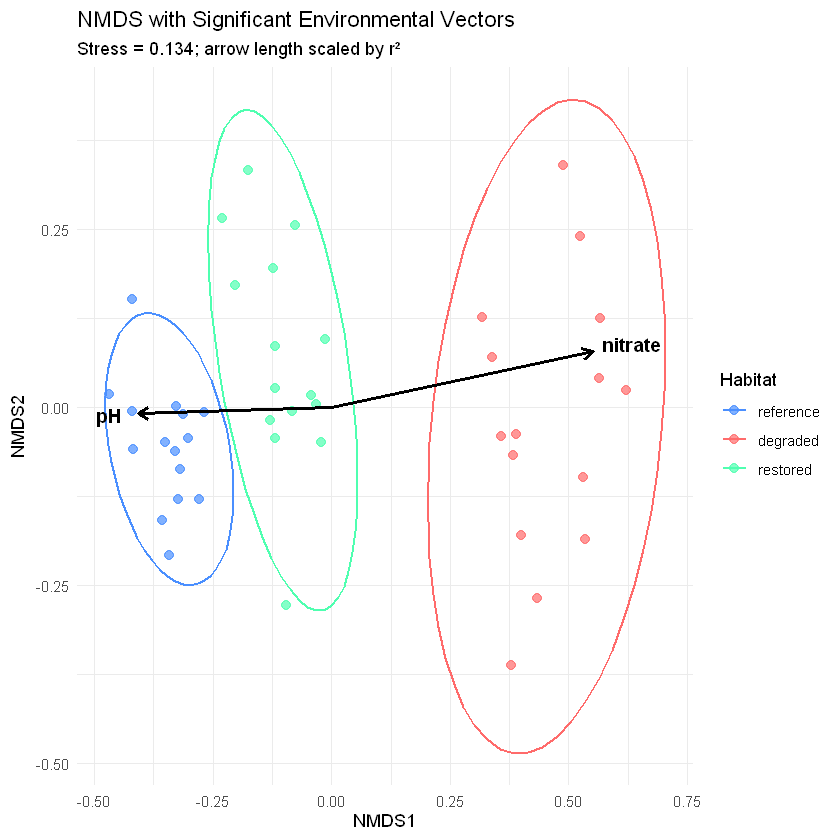

In [5]:
# ── Fit environmental vectors ─────────────────────────────────────────────────
env_mat <- env_df %>% select(pH, nitrate) %>% as.matrix()
rownames(env_mat) <- env_df$site

env_fit <- vegan::envfit(
  nmds,
  env          = env_mat,
  permutations = 999
)
print(env_fit)
# r2: proportion of variance in ordination explained by each variable
# Pr(>r): permutation p-value

# ── Extract envfit vectors for ggplot2 ───────────────────────────────────────
env_vectors <- as.data.frame(vegan::scores(env_fit, display = "vectors")) %>%
  rownames_to_column("variable") %>%
  mutate(
    r2 = env_fit$vectors$r,
    p  = env_fit$vectors$pvals,
    # Scale by r² for display: longer arrows = stronger correlation
    NMDS1 = NMDS1 * r2,
    NMDS2 = NMDS2 * r2
  ) %>%
  filter(p < 0.05)   # only plot significant vectors

# ── Add env vectors to ordination ────────────────────────────────────────────
ggplot() +
  geom_point(data = site_scores,
             aes(x = NMDS1, y = NMDS2, color = habitat),
             size = 2.5, alpha = 0.7) +
  stat_ellipse(data = site_scores,
               aes(x = NMDS1, y = NMDS2, color = habitat),
               level = 0.95, linewidth = 0.7) +
  geom_segment(data = env_vectors,
               aes(x = 0, y = 0, xend = NMDS1, yend = NMDS2),
               arrow = arrow(length = unit(0.25, "cm")),
               color = "black", linewidth = 1.0) +
  geom_text(data = env_vectors,
            aes(x = NMDS1 * 1.15, y = NMDS2 * 1.15, label = variable),
            size = 4, fontface = "bold") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  labs(title = "NMDS with Significant Environmental Vectors",
       subtitle = sprintf("Stress = %.3f; arrow length scaled by r²", nmds$stress),
       color = "Habitat") +
  theme_minimal()

---

## Reporting Results

In [6]:
cat(sprintf("NMDS stress: %.4f\n", nmds$stress))
cat(sprintf("Dimensions: %d\n", nmds$ndim))
cat(sprintf("Distance metric: Bray-Curtis\n"))
cat(sprintf("Number of random starts: %d\n", nmds$tries))

cat("\nEnvironmental vector correlations:\n")
print(env_fit$vectors)

# Standard reporting format:
# "Community composition was visualized using non-metric multidimensional
#  scaling (NMDS; Bray-Curtis dissimilarity; k = 2; vegan package, Oksanen
#  et al. YEAR) with a final stress of 0.XXX, indicating [good/acceptable]
#  representation of the dissimilarity structure. Reference sites clustered
#  distinctly from degraded sites in ordination space. Environmental vectors
#  fitted to the ordination indicated that pH (r² = X.XX, p = .XXX) and
#  nitrate concentration (r² = X.XX, p = .XXX) were significantly
#  associated with community composition gradients."
#
# Always cite: Oksanen J et al. (YEAR) vegan: Community Ecology Package.
# R package version X.X-XX.

NMDS stress: 0.1343
Dimensions: 2
Distance metric: Bray-Curtis
Number of random starts: 100

Environmental vector correlations:
            NMDS1     NMDS2     r2 Pr(>r)    
pH      -0.999770 -0.021542 0.5502  0.001 ***
nitrate  0.990130  0.140141 0.6764  0.001 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Permutation: free
Number of permutations: 999


---

## Common Pitfalls

**1. Not reporting stress**  
Stress is the primary quality metric for NMDS. Always report the final stress value and interpret it. A plot without a stress value cannot be evaluated.

**2. Accepting high stress (> 0.20)**  
If stress exceeds 0.20, the 2D ordination is poorly representing the true dissimilarity structure. Try k = 3, a different distance metric, or fewer species (remove very rare species).

**3. Using a single random start**  
NMDS is iterative and can converge to local minima. Always use `trymax` ≥ 20-100 to ensure the global minimum is found. `metaMDS()` runs multiple starts by default.

**4. Interpreting NMDS axes as meaningful dimensions**  
Unlike PCA, NMDS axes have no inherent meaning. The axes can be freely rotated without changing the solution. Do not assign biological meaning to "NMDS1" or "NMDS2" — interpret the clusters and the vectors instead.

**5. Overlaying environmental vectors without permutation tests**  
Any vector can be drawn on an ordination. Only vectors with significant permutation-based p-values from `envfit()` should be displayed.

**6. Not checking dispersion before concluding groups differ**  
Group separation in NMDS could reflect differences in centroid OR in dispersion. Always pair NMDS visualization with `betadisper()` and PERMANOVA.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*